# H-code (`H_six`) integration — roadmap Steps 1–3 status

Checks the maintainers' roadmap against the current **`h6-msd`** branch; every claim is
reproduced by the cell below it.

| Step | Ask | Status |
|---|---|---|
| **1** | H-code family as a reusable QEC patch — canonical logical + coordinate convention, stim detector-slice visualization, baseline memory experiment via generic CSS coloration extraction | ✅ **complete** |
| **2** | Flagged state preparation & syndrome extraction, low-weight fault audits, O(p²) conditional logical-error scaling under post-selection, auto-generated detectors | ✅ **complete** — circuit fault distance via stim's `shortest_graphlike_error` on the circuit-level-noised circuit; bare, `\|00⟩_L`-encoded, and **flag-verified** (native-builder) memory are all circuit fault distance ≥ 2 with MC slope ≈ 2; flag detectors post-selected |
| **3** | Level-1 Magic-H6 Clifford proxy + its expected O(p²) output suppression | ✗ **not met on this branch** — proxy code split to `feat/magic-h6-protocol`; rebuilt here it runs and post-selects, but the `\|++⟩_L` distillation path is genuinely circuit fault distance 1, so its conditional output LER is **O(p)** under circuit-level noise. Magic-H6's O(p²) is suppression of *input* `\|H⟩` infidelity `p_in → p_in²`, which needs a dedicated `p_in` channel that is not implemented |

In [1]:
import subprocess
import numpy as np
import stim
import matplotlib.pyplot as plt

print("branch :", subprocess.run(["git","rev-parse","--abbrev-ref","HEAD"],capture_output=True,text=True).stdout.strip())
print("commit :", subprocess.run(["git","rev-parse","--short","HEAD"],capture_output=True,text=True).stdout.strip())
print("stim   :", stim.__version__)

branch : h6-msd
commit : 019aeab
stim   : 1.16.0


---
## Step 1 — H-code family as a reusable LightStim QEC patch

`HSixCode` is the smallest member of the H-code family: the self-dual `[[6,2,2]]` CSS code
(`k=2`, `d=2`), base code of Quantinuum's Magic-H6 protocol.

In [2]:
from lightstim.qec_code.H_six import (
    HSixCode, HSixExtractionBlock, HSixLogicalXCheckBlock,
    HSixLogicalOpSet, get_dist_circ, get_ft_init_circ, encoded_memory_circuit,
)

code = HSixCode()
info = code.get_info()
{k: info[k] for k in ("n", "k", "d", "num_data_qubits", "num_syndrome_qubits", "num_logicals")}

{'n': 6,
 'k': 2,
 'd': 2,
 'num_data_qubits': 6,
 'num_syndrome_qubits': 4,
 'num_logicals': 2}

### Canonical logical convention

```
S^X_1 = X0 X1 X2 X3      S^Z_1 = Z0 Z1 Z2 Z3
S^X_2 = X2 X3 X4 X5      S^Z_2 = Z2 Z3 Z4 Z5
X0_L  = X0 X2 X4         Z0_L  = Z0 Z2 Z4
X1_L  = X1 X3 X5         Z1_L  = Z1 Z3 Z5
```

Logicals registered `(X0, Z0, X1, Z1)`. X and Z checks share support → **self-dual**
(`Hx == Hz`), transversal H is logical H, transversal S is logical S.
`get_stabs` / `get_logicals` are bit-for-bit ports of `Code614.py`.

In [3]:
for s in code.stabilizers:
    print(f"  {s['type']}-check  supp {s['data_indices']}  ancilla {s['syn_idx']}")
print()
for op in code.logical_ops:
    print(f"  {op['type']}{op['data_indices']}")

Hx, Hz = code.get_parity_check_matrix()
assert np.array_equal(Hx, Hz) and np.all((Hx @ Hz.T) % 2 == 0)
assert code.num_logicals == 6 - 2 - 2 == 2
assert HSixCode.get_stabs([1,1,1,1,0,0]) == [0,0]
assert HSixCode.get_logicals([1,0,1,0,1,0]) == [1,0]
print("\nself-dual (Hx == Hz):", np.array_equal(Hx, Hz),
      "| CSS commuting:", np.all((Hx @ Hz.T) % 2 == 0),
      "| k:", code.num_logicals, "| get_stabs/get_logicals match Code614.py")

  X-check  supp [0, 1, 2, 3]  ancilla 6
  X-check  supp [2, 3, 4, 5]  ancilla 7
  Z-check  supp [0, 1, 2, 3]  ancilla 8
  Z-check  supp [2, 3, 4, 5]  ancilla 9

  X[0, 2, 4]
  Z[0, 2, 4]
  X[1, 3, 5]
  Z[1, 3, 5]

self-dual (Hx == Hz): True | CSS commuting: True | k: 2 | get_stabs/get_logicals match Code614.py


### Coordinate convention

No 2D locality; coordinates feed plotting and role inference only. Data qubit `i` at `(2i, 0)`;
X ancillas `y=+1`, Z ancillas `y=-1`, centred over support. `HSixCode(h_check_ancillas=2)` adds
bare ancillas on `y=3` (used by the H-check and the flag gadget); `shift=(dx,dy)` offsets
everything for multi-block layouts.

In [4]:
for idx, (x, y) in code.qubit_coords.items():
    role = ("data" if idx in code.data_indices
            else "X-anc" if idx in code.syndrome_indices_x
            else "Z-anc" if idx in code.syndrome_indices_z else "bare")
    print(f"  q{idx:<2} ({x:>4.1f}, {y:>4.1f})  {role}")

  q0  ( 0.0,  0.0)  data
  q1  ( 2.0,  0.0)  data
  q2  ( 4.0,  0.0)  data
  q3  ( 6.0,  0.0)  data
  q4  ( 8.0,  0.0)  data
  q5  (10.0,  0.0)  data
  q6  ( 3.0,  1.0)  X-anc
  q7  ( 7.0,  1.0)  X-anc
  q8  ( 3.0, -1.0)  Z-anc
  q9  ( 7.0, -1.0)  Z-anc


### Detector-slice visualization

Visualization is stim's built-in `Circuit.diagram("detslice-with-ops-svg")` over the patch's
own `MemoryExperiment` circuit — the same tool every other code's notebook uses. Each syndrome
round shows the two X checks and the two Z checks over the same 4-qubit supports: the
CSS-self-dual signature of the `[[6,2,2]]` code.

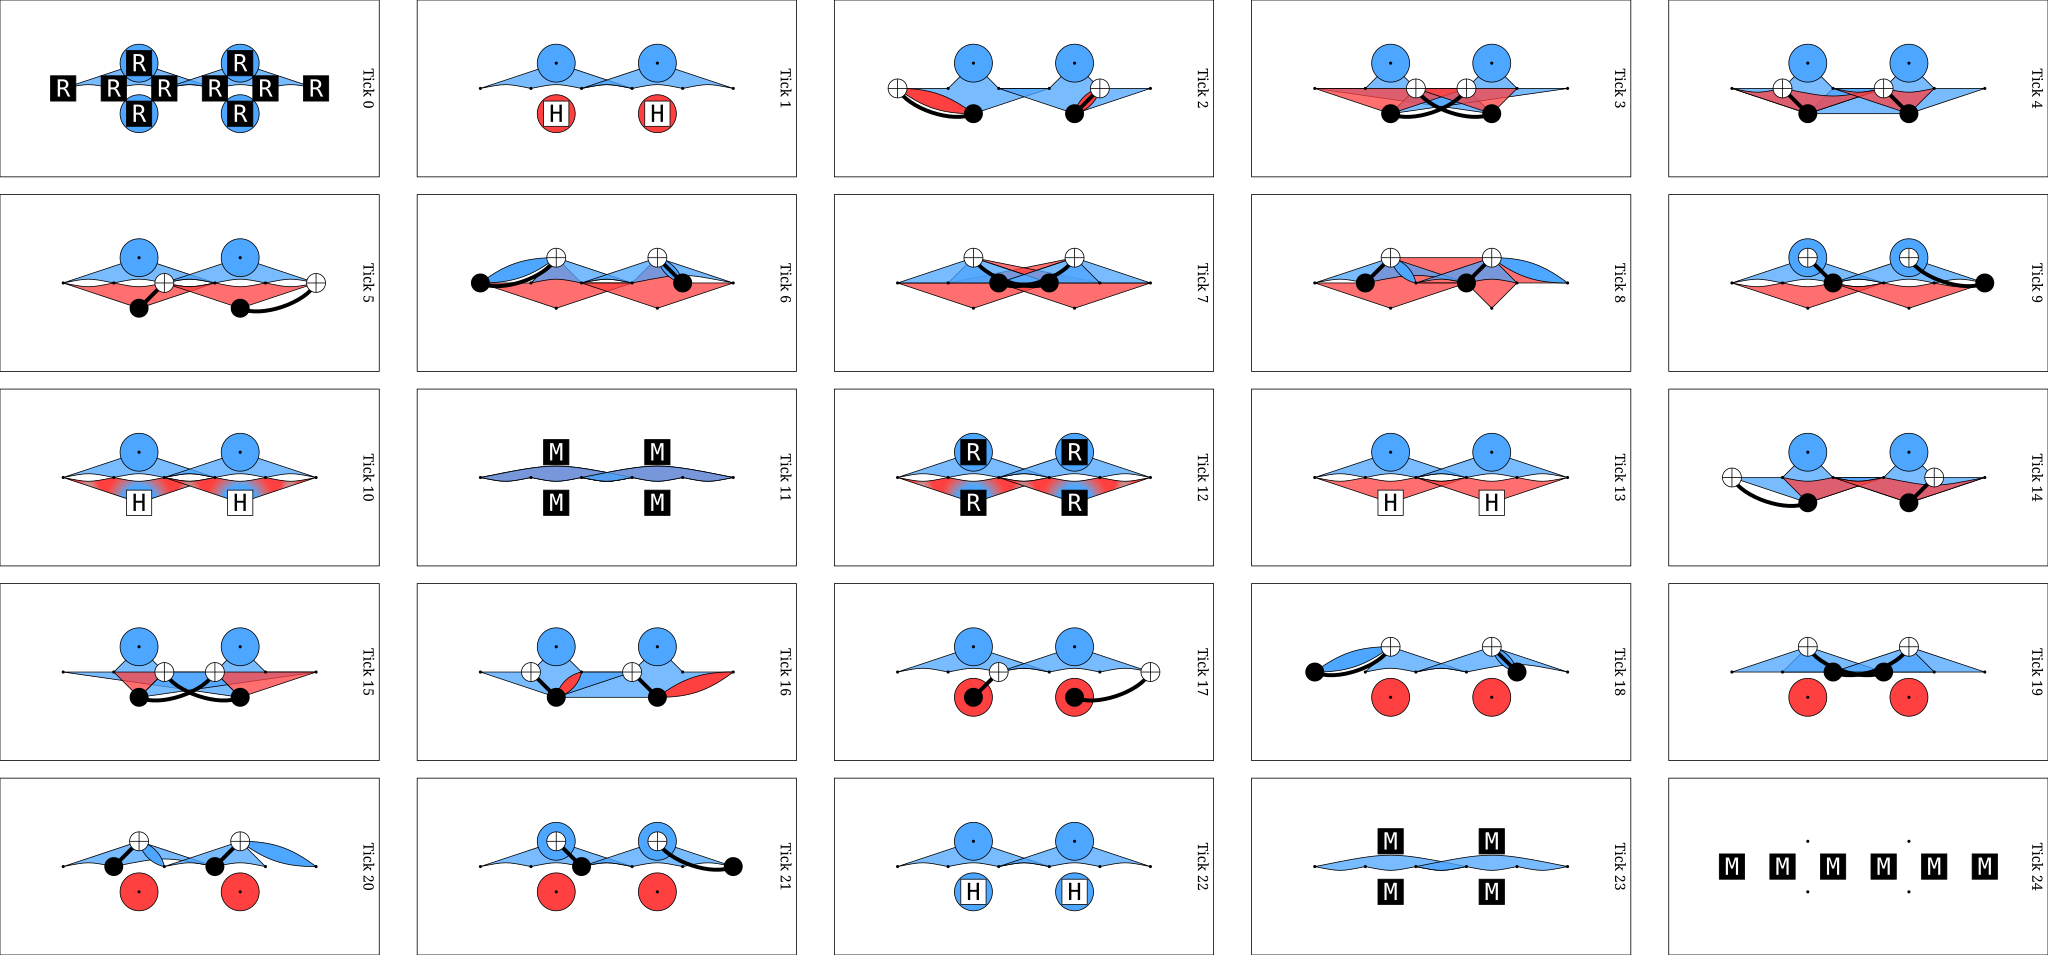

In [5]:
from lightstim.protocols.memory import MemoryExperiment

circ = MemoryExperiment(qec_patch=HSixCode(), rounds=2, basis="Z", noise_params=None).build()
circ.without_noise().diagram("detslice-with-ops-svg")

### Baseline memory experiment (generic CSS coloration extraction)

`HSixExtractionBlock` **is** `GenericCSSColorationExtractionBlock` — no geometric schedule, so
SE colours the X and Z Tanner graphs independently. `MemoryExperiment` uses it automatically.

In [6]:
from lightstim.protocols.memory import MemoryExperiment
from lightstim.qec_code.generic_css import GenericCSSColorationExtractionBlock

assert HSixExtractionBlock is GenericCSSColorationExtractionBlock
assert HSixCode.default_extraction_block_class is HSixExtractionBlock

for basis in ("Z", "X"):
    circ = MemoryExperiment(qec_patch=HSixCode(), rounds=3, basis=basis, noise_params=None).build()
    dets, obs = circ.compile_detector_sampler().sample(4096, separate_observables=True)
    circ.detector_error_model(decompose_errors=True)
    print(f"  basis {basis}:  {circ.num_detectors} detectors, {circ.num_observables} observables, "
          f"noiseless all-zero: {(not dets.any()) and (not obs.any())}")
print("\nStep 1: COMPLETE.")

  basis Z:  12 detectors, 2 observables, noiseless all-zero: True
  basis X:  12 detectors, 2 observables, noiseless all-zero: True

Step 1: COMPLETE.


---
## Step 2 — flagged prep, low-weight fault audit, O(p²) under post-selection

### 2a. Fault-distance tooling — stim's `Circuit.shortest_graphlike_error`

The low-weight fault audit is stim's built-in one: inject circuit-level noise with
`NoiseInjector.from_circuit_level` (one Pauli channel per physical gate, per LightStim's noise
model), then call `Circuit.shortest_graphlike_error()`. The returned list is the smallest set
of error mechanisms that flips a logical observable while firing no detector; its **length is
the circuit fault distance**.

* length ≥ 2 ⇔ no single fault flips a logical undetected ⇔ **O(p²)** conditional logical-error
  rate under detector post-selection;
* length 1 ⇔ a single undetected fault flips a logical ⇒ **O(p)**.

Because `NoiseInjector` places a channel after every physical gate, the DEM stim builds already
sees gate-level faults individually — no manual atomisation needed — so this verdict agrees
with the Monte-Carlo slope fit below.

In [7]:
from lightstim.noise.config import NoiseConfig
from lightstim.noise.injector import NoiseInjector


def circuit_fault_distance(circuit, p=1e-3):
    """Length of the shortest graphlike error of the circuit-level-noised circuit."""
    cfg = NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p)
    noisy = NoiseInjector.from_circuit_level(
        cfg, list(range(circuit.num_qubits))
    ).inject_noise(circuit)
    return len(noisy.shortest_graphlike_error())


for basis in ("Z", "X"):
    circ = MemoryExperiment(qec_patch=HSixCode(), rounds=2, basis=basis, noise_params=None).build()
    d = circuit_fault_distance(circ)
    print(f"  bare memory, basis {basis}: circuit fault distance {d}  ({'>= 2 -> O(p^2)' if d >= 2 else 'O(p)'})")

  bare memory, basis Z: circuit fault distance 2  (>= 2 -> O(p^2))
  bare memory, basis X: circuit fault distance 2  (>= 2 -> O(p^2))


### 2b. Encoded `|00>_L` memory and flag-verified prep — all O(p²), builder-native

`encoded_memory_circuit` prepares a `|00>_L` codeword through the builder (each encoder gate
its own unitary block, so `NoiseInjector` models per-gate noise) and runs native syndrome
extraction — the tracker auto-generates every stabilizer detector.

`flag_verified=True` runs the Fig. 5 (arXiv:2506.14688) flag-verified encoder: two ancillas
hooked onto the encoder's control qubits (0, 2), disentangled + measured after, and the caller
**post-selects on the two flag detectors**.

  bare memory               : fault distance=2  MC slope=2.31  detectors=8


  encoded |00>_L            : fault distance=2  MC slope=2.20  detectors=10


  encoded |00>_L, flagged   : fault distance=2  MC slope=1.96  detectors=12


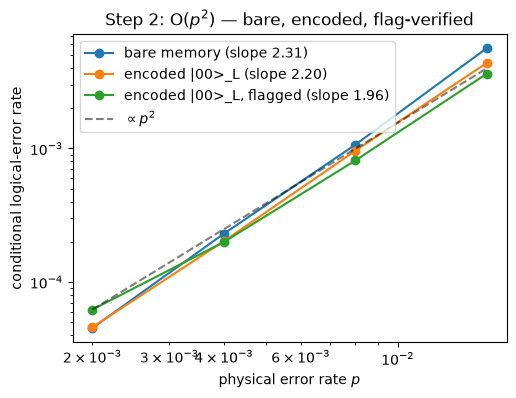

In [8]:
def conditional_ler(circuit_fn, ps, shots=150_000):
    accs, lers = [], []
    for p in ps:
        c = circuit_fn(p)
        d, o = c.compile_detector_sampler().sample(shots, separate_observables=True)
        keep = ~d.any(axis=1)
        accs.append(keep.mean())
        lers.append(o[keep].any(axis=1).mean() if keep.sum() else np.nan)
    return np.array(accs), np.array(lers)

def circuit_level(build_fn):
    def f(p):
        c = build_fn()
        cfg = NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p)
        return NoiseInjector.from_circuit_level(cfg, list(range(c.num_qubits))).inject_noise(c)
    return f

ps = np.array([0.002, 0.004, 0.008, 0.016])
variants = {
    "bare memory":               lambda: MemoryExperiment(qec_patch=HSixCode(), rounds=2, basis="Z", noise_params=None).build(),
    "encoded |00>_L":            lambda: encoded_memory_circuit(basis="Z", rounds=2, encoder="zero_zero")[0],
    "encoded |00>_L, flagged":   lambda: encoded_memory_circuit(basis="Z", rounds=2, encoder="zero_zero", flag_verified=True)[0],
}
slopes = {}
fig, ax = plt.subplots(figsize=(5.6, 4))
for name, fn in variants.items():
    circ = fn()
    dist = circuit_fault_distance(circ)
    acc, ler = conditional_ler(circuit_level(fn), ps)
    s = np.polyfit(np.log(ps), np.log(ler), 1)[0]
    slopes[name] = s
    ax.loglog(ps, ler, "o-", label=f"{name} (slope {s:.2f})")
    print(f"  {name:26s}: fault distance={dist}  MC slope={s:.2f}  "
          f"detectors={circ.num_detectors}")
ax.loglog(ps, ler[0]*(ps/ps[0])**2, "k--", alpha=0.5, label="$\\propto p^2$")
ax.set_xlabel("physical error rate $p$"); ax.set_ylabel("conditional logical-error rate")
ax.set_title("Step 2: O($p^2$) — bare, encoded, flag-verified"); ax.legend(); plt.show()

In [9]:
# the flag-verified circuit adds exactly two post-selected flag detectors
plain, _  = encoded_memory_circuit(basis="Z", rounds=2, encoder="zero_zero")
flagged, info = encoded_memory_circuit(basis="Z", rounds=2, encoder="zero_zero", flag_verified=True)
print("plain   detectors:", plain.num_detectors)
print("flagged detectors:", flagged.num_detectors, " flag detector indices:", info["flag_detector_indices"])
d, _ = flagged.compile_detector_sampler().sample(2048, separate_observables=True)
print("flag detectors deterministic-0 noiseless:", not d[:, info["flag_detector_indices"]].any())
flagged.detector_error_model(decompose_errors=True)
print("flag-verified DEM compiles (graphlike): OK")

plain   detectors: 10
flagged detectors: 12  flag detector indices: [0, 1]
flag detectors deterministic-0 noiseless: True
flag-verified DEM compiles (graphlike): OK


### 2c. Flag-verified `|00>_L` encoder — state check

`get_ft_init_circ` is the Fig. 5 encoder; here is the raw state it prepares.

In [10]:
circ = get_ft_init_circ(data=[0, 1, 2, 3, 4, 5], flags=[6, 7])
sim = stim.TableauSimulator(); sim.do(circ)
print("flag measurements (noiseless):", sim.current_measurement_record()[-2:], "-> both deterministically 0")
for chk in ("+XXXXII", "+IIXXXX", "+ZZZZII", "+IIZZZZ"):
    assert sim.peek_observable_expectation(stim.PauliString(chk + "II")) == 1
assert sim.peek_observable_expectation(stim.PauliString("+ZIZIZIII")) == 1   # Z0_L
assert sim.peek_observable_expectation(stim.PauliString("+IZIZIZII")) == 1   # Z1_L
print("prepares |00>_L: all four stabilizers +1, Z0_L = Z1_L = +1")

flag measurements (noiseless): [False, False] -> both deterministically 0
prepares |00>_L: all four stabilizers +1, Z0_L = Z1_L = +1


### Step 2 verdict — ✅ complete

| item | status |
|---|---|
| fault-distance check = stim's `shortest_graphlike_error` on the circuit-level-noised circuit, code-agnostic | ✅ |
| bare memory: circuit fault distance ≥ 2, O(p²) (`shortest_graphlike_error` + MC slope ≈ 2) | ✅ |
| `encoded_memory_circuit` — builder-native `\|00>_L` encoded memory, O(p²) | ✅ |
| **flag-verified prep** (`flag_verified=True`) — native builder, two post-selected flag detectors, O(p²) | ✅ |
| `shortest_graphlike_error` / MC agree across all three | ✅ |

*(The `\|00>_L` encoded Z-memory turned out not to need flag verification — under
generic-CSS extraction it is already circuit fault distance ≥ 2. The genuinely
distance-1 circuit is the `\|++>_L` distillation path below — roadmap stage 3.)*

---
## Step 3 — Level-1 Magic-H6 Clifford proxy + O(p²) output suppression

The proxy module (`lightstim/protocols/magic_h6_benchmark.py`) is **not on `h6-msd`** — it was
split to `feat/magic-h6-protocol` so stages 1–2 can merge first. Rebuilt below from on-branch
primitives.

In [11]:
from lightstim.ir.builder import CircuitBuilder
from lightstim.ir.qec_system import QECSystem
from lightstim.ir.tracker import SyndromeTracker

def level1_proxy_circuit():
    # |0>^6 -> get_dist_circ -> |++>_L, one native SE round, Bell-pair H-check, X readout.
    system = QECSystem(); system.add_patch(HSixCode(h_check_ancillas=2), name="c622")
    tr = SyndromeTracker(system.num_qubits, expected_num_logicals=system.num_logicals)
    b = CircuitBuilder(tr, system, if_detector=True); b.write_coordinates()
    d = sorted(system.data_indices)
    b.initialize({q: "Z" for q in d}, n=system.num_qubits)
    b.apply_unitary_block(get_dist_circ(d))
    b.apply_syndrome_extraction(circuit_chunk=HSixExtractionBlock(system).circuit, rounds=1)
    b.apply_syndrome_extraction(circuit_chunk=HSixLogicalXCheckBlock(system).circuit, rounds=1)
    b.apply_data_readout({q: "X" for q in d})
    return b.circuit

circ = level1_proxy_circuit()
d0, o0 = circ.compile_detector_sampler().sample(4096, separate_observables=True)
print(f"{circ.num_detectors} detectors, {circ.num_observables} observables (X0_L, X1_L), "
      f"noiseless all-zero: {(not d0.any()) and (not o0.any())}")

cfg = NoiseConfig(p_1q=1e-3, p_2q=1e-3, p_meas=1e-3, p_reset=1e-3)
noisy = NoiseInjector.from_circuit_level(cfg, list(range(circ.num_qubits))).inject_noise(circ)
err = noisy.shortest_graphlike_error()
print(f"\nshortest graphlike error: length {len(err)}  ->  circuit fault distance {len(err)}")
for e in err:
    loc = e.circuit_error_locations[0]
    terms = ", ".join(str(t) for t in e.dem_error_terms)
    paulis = "*".join(str(p) for p in loc.flipped_pauli_product)
    print(f"   flips [{terms}]  via  {paulis}  (undetected, on the encoder spine / H-check ancilla)")

7 detectors, 2 observables (X0_L, X1_L), noiseless all-zero: True

shortest graphlike error: length 1  ->  circuit fault distance 1
   flips [L0]  via  X10[coords 0,3]  (undetected, on the encoder spine / H-check ancilla)


  p=0.0010  accept=0.950  post-selected output LER=6.523e-03
  p=0.0020  accept=0.903  post-selected output LER=1.276e-02
  p=0.0040  accept=0.815  post-selected output LER=2.649e-02
  p=0.0080  accept=0.664  post-selected output LER=5.302e-02

  log-log slope = 1.01   (O(p^2) would be ~2)


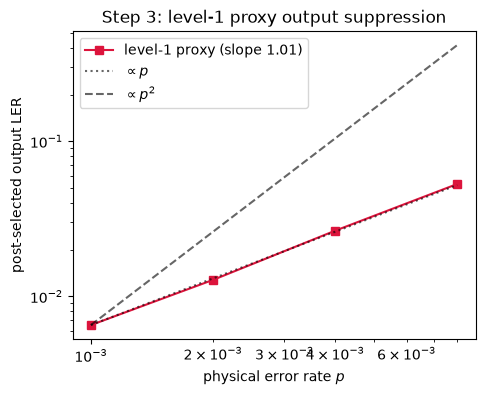

In [12]:
def proxy_noisy(p):
    cfg = NoiseConfig(p_1q=p, p_2q=p, p_meas=p, p_reset=p)
    return NoiseInjector.from_circuit_level(cfg, list(range(circ.num_qubits))).inject_noise(circ)

ps3 = np.array([0.001, 0.002, 0.004, 0.008])
acc3, ler3 = conditional_ler(proxy_noisy, ps3, shots=200_000)
slope3 = np.polyfit(np.log(ps3), np.log(ler3), 1)[0]
for p, a, l in zip(ps3, acc3, ler3):
    print(f"  p={p:.4f}  accept={a:.3f}  post-selected output LER={l:.3e}")
print(f"\n  log-log slope = {slope3:.2f}   (O(p^2) would be ~2)")

fig, ax = plt.subplots(figsize=(5.2, 4))
ax.loglog(ps3, ler3, "s-", color="crimson", label=f"level-1 proxy (slope {slope3:.2f})")
ax.loglog(ps3, ler3[0]*(ps3/ps3[0]),    "k:",  alpha=0.6, label="$\\propto p$")
ax.loglog(ps3, ler3[0]*(ps3/ps3[0])**2, "k--", alpha=0.6, label="$\\propto p^2$")
ax.set_xlabel("physical error rate $p$"); ax.set_ylabel("post-selected output LER")
ax.set_title("Step 3: level-1 proxy output suppression"); ax.legend(); plt.show()

### Step 3 verdict — ✗ not met

* The level-1 Clifford proxy **runs and post-selects** (noiseless: all-zero).
* Its `|++>_L` `get_dist_circ` encoder + Bell-pair H-check is **circuit fault distance 1** —
  `shortest_graphlike_error` above returns a single undetected fault on the encoder's
  control-qubit spine / H-check ancilla prep. So under circuit-level noise the post-selected
  output LER is **O(p)** (slope ≈ 1).
* Magic-H6's O(p²) is a distillation gain in the **input `|H>` infidelity** `p_in` (`p_in →
  p_in²`), measured against a dedicated `p_in` injection channel (cf.
  `tg_distillation.estimate_p_in`). That channel is not implemented, so the maintainers'
  correctness criterion is **not demonstrated**. Proxy code + `p_in` calibration + a
  flag-verified `|++>_L` encoder are the substance of the stage-3/4 follow-up
  (`feat/magic-h6-protocol`).

---
## Summary

| Step | Status | On `h6-msd` | Missing |
|---|---|---|---|
| 1 | ✅ | `HSixCode` + conventions + stim `detslice` visualization + generic-CSS memory baseline (noiseless-clean, DEM-valid, `k=2`) | — |
| 2 | ✅ | fault distance via stim `shortest_graphlike_error`; bare, `\|00>_L`-encoded and **flag-verified** memory all circuit fault distance ≥ 2 with MC slope ≈ 2; flag detectors post-selected | — |
| 3 | ✗ | level-1 proxy rebuildable from on-branch primitives; runs + post-selects; `shortest_graphlike_error` shows it is distance 1 | proxy module (on `feat/magic-h6-protocol`); a flag-verified `\|++>_L` encoder; a `p_in` infidelity channel; O(p²)/O(p⁴) criteria in `p_in` |

**Clean initial merge:** Steps 1 and 2 (what is on `h6-msd`). The L1/L2 proxies, a flag-verified
`\|++>_L` encoder, and the `p_in` O(p²)/O(p⁴) criteria are the `feat/magic-h6-protocol`
follow-ups.